# 1D Dirichlet Laplacian — Variational PINN

**Problem:** $-u''(x) = \lambda u(x)$ on $\Omega = (0, \pi)$ with $u(0)=u(\pi)=0$.

**Analytic reference:** $u_k(x) = \sqrt{2/\pi}\,\sin(kx)$, $\lambda_k = k^2$, for $k=1,2,\ldots$

**Method (advisor's formulation):**
1. Hard Dirichlet BC via $B(x) = x(\pi-x)$: we define $u_{\theta_k}(x) = B(x) \cdot N_{\theta_k}(x)$ so the BC is satisfied by construction.
2. **Rayleigh-quotient loss** $\mathcal L = \frac{\mathbb E[|u'|^2]}{\mathbb E[u^2]}$ (avoids second derivatives; scale-invariant).
3. **Sequential training** with orthogonality penalty $\alpha_\text{orth} \sum_{j<k} (\mathbb E[u_k u_j])^2$ to avoid mode collapse onto already-found modes.

We train the first 5 eigenmodes and compare against the analytic eigenpairs.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import torch
import matplotlib.pyplot as plt

from pinns.device import select_device, device_info
from pinns.equations import laplace_1d as lap

device = select_device()
print(f"Device: {device_info(device)}")
torch.manual_seed(0)
np.random.seed(0)

Device: mps (Apple GPU)


/Users/anna/miniconda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Train the first 5 modes sequentially

In [2]:
N_MODES = 5
N_EPOCHS = 5_000
LR = 1e-3
ALPHA_ORTH = 100.0
N_INTERIOR = 1024

models, histories = lap.train_first_n_modes(
    n_modes=N_MODES,
    device=device,
    n_epochs=N_EPOCHS,
    lr=LR,
    alpha_orth=ALPHA_ORTH,
    n_interior=N_INTERIOR,
    log_every=500,
)
print(f"Trained {len(models)} modes.")

Trained 5 modes.


## 2. Evaluate vs analytic

In [3]:
results = lap.evaluate_all(models, device, nx=500)

print(f"{'k':>3} {'λ_true':>10} {'λ_hat':>10} {'|Δλ|/λ':>10} {'rel-L2 u':>10}")
print("-" * 48)
for r in results:
    print(f"{r['k']:>3} {r['lambda_true']:>10.4f} {r['lambda_hat']:>10.4f} {r['lambda_rel_err']:>10.4f} {r['rel_l2']:>10.4f}")

  k     λ_true      λ_hat     |Δλ|/λ   rel-L2 u
------------------------------------------------
  1     1.0000     1.0043     0.0043     0.0042
  2     4.0000     4.0290     0.0073     0.0200
  3     9.0000     9.1150     0.0128     0.1240
  4    16.0000    16.1222     0.0076     0.0873
  5    25.0000    26.9587     0.0783     0.4154


## 3. Predicted vs analytic eigenfunctions

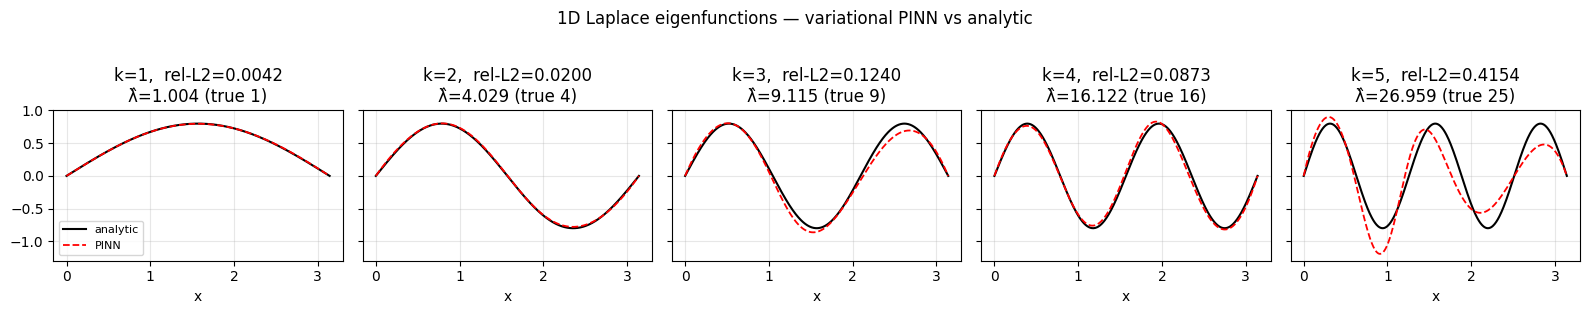

Saved: ../results/fig_laplace_1d_modes.png


In [4]:
nx = 500
x_eval = np.linspace(lap.X_MIN, lap.X_MAX, nx)

fig, axes = plt.subplots(1, N_MODES, figsize=(3.2 * N_MODES, 3), sharey=True)
for k_idx, (m, r) in enumerate(zip(models, results)):
    k = k_idx + 1
    u_ref, _ = lap.reference_eigenmode(k, x_eval)
    u_pred = lap.predict_eigenmode(m, x_eval, device)
    u_pred_n = lap._l2_normalise(u_pred)
    if float(np.dot(u_pred_n, u_ref)) < 0.0:
        u_pred_n = -u_pred_n

    ax = axes[k_idx]
    ax.plot(x_eval, u_ref, 'k-', lw=1.5, label='analytic')
    ax.plot(x_eval, u_pred_n, 'r--', lw=1.3, label='PINN')
    ax.set_title(f"k={k},  rel-L2={r['rel_l2']:.4f}\nλ̂={r['lambda_hat']:.3f} (true {r['lambda_true']:.0f})")
    ax.set_xlabel('x'); ax.grid(alpha=0.3)
    if k_idx == 0: ax.legend(fontsize=8)

fig.suptitle('1D Laplace eigenfunctions — variational PINN vs analytic', y=1.03)
plt.tight_layout()
plt.savefig('../results/fig_laplace_1d_modes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../results/fig_laplace_1d_modes.png')

## 4. Rayleigh-quotient convergence

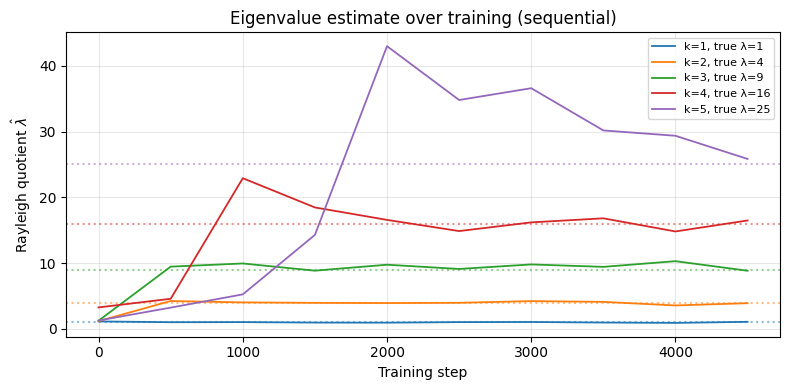

Saved: ../results/fig_laplace_1d_rayleigh.png


In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
for k_idx, h in enumerate(histories):
    k = k_idx + 1
    ax.plot(h['step'], h['lambda_hat'], label=f"k={k}, true λ={k**2}", lw=1.3)
    ax.axhline(k ** 2, ls=':', color=f'C{k_idx}', alpha=0.5)
ax.set_xlabel('Training step')
ax.set_ylabel(r'Rayleigh quotient $\hat\lambda$')
ax.set_title('Eigenvalue estimate over training (sequential)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../results/fig_laplace_1d_rayleigh.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../results/fig_laplace_1d_rayleigh.png')

## 5. Save results

In [6]:
import json
summary = {
    'config': {
        'n_modes': N_MODES,
        'n_epochs': N_EPOCHS,
        'lr': LR,
        'alpha_orth': ALPHA_ORTH,
        'n_interior': N_INTERIOR,
        'hidden_dims': [32, 32, 32],
    },
    'results': results,
}
with open('../results/laplace_1d_results.json', 'w') as f:
    json.dump(summary, f, indent=2)
print('Saved: ../results/laplace_1d_results.json')

for k_idx, m in enumerate(models):
    torch.save({'state_dict': m.state_dict(), 'k': k_idx + 1},
               f'../checkpoints/laplace_1d_mode{k_idx+1}.pt')
print(f'Saved: checkpoints/laplace_1d_mode{{1..{N_MODES}}}.pt')

Saved: ../results/laplace_1d_results.json
Saved: checkpoints/laplace_1d_mode{1..5}.pt
